INFO       The synaptic equation for the variable etrace does not specify whether it should be integrated at every timestep ('clock-driven') or only at spiking events ('event-driven'). It will be integrated at every timestep which can slow down your simulation unnecessarily if you only need the values of this variable whenever a spike occurs. Specify the equation as clock-driven explicitly to avoid this warning. [brian2.synapses.synapses.clock_driven]
INFO       No numerical integration method specified for group 'synapses_1', using method 'exact' (took 0.00s). [brian2.stateupdaters.base.method_choice]
INFO       No numerical integration method specified for group 'synapses_3', using method 'exact' (took 0.00s). [brian2.stateupdaters.base.method_choice]


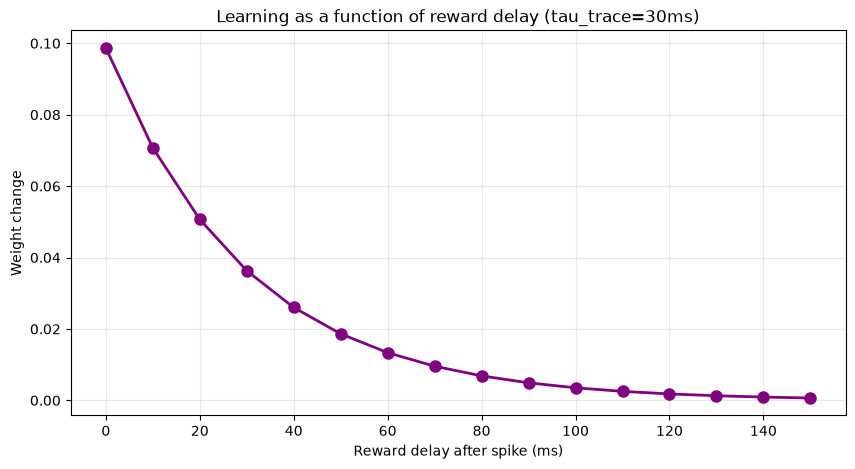

Reward delay → Weight change:
  0ms delay → Δw = 0.0987
  10ms delay → Δw = 0.0707
  20ms delay → Δw = 0.0507
  30ms delay → Δw = 0.0363
  40ms delay → Δw = 0.0260
  50ms delay → Δw = 0.0186
  60ms delay → Δw = 0.0134
  70ms delay → Δw = 0.0096
  80ms delay → Δw = 0.0069
  90ms delay → Δw = 0.0049
  100ms delay → Δw = 0.0035
  110ms delay → Δw = 0.0025
  120ms delay → Δw = 0.0018
  130ms delay → Δw = 0.0013
  140ms delay → Δw = 0.0009
  150ms delay → Δw = 0.0007


In [4]:
start_scope()

tau_mem = 10*ms
tau_trace = 30*ms

delays = np.arange(0, 151, 10)
weight_changes = []

for delay in delays:
    start_scope()
    
    eqs = '''
    dv/dt = -v/tau_mem : 1
    '''
    output = NeuronGroup(1, eqs, threshold='v>0.8', reset='v=0', method='exact')
    
    input_neuron = SpikeGeneratorGroup(1, [0], [20]*ms)
    
    stdp_eqs = '''
    w : 1
    detrace/dt = -etrace/tau_trace : 1
    '''
    
    on_pre = '''
    v_post += w
    etrace += 1.0
    '''
    
    S = Synapses(input_neuron, output, stdp_eqs, on_pre=on_pre)
    S.connect()
    S.w = 0.9
    S.etrace = 0
    
    trace_mon = StateMonitor(S, 'etrace', record=True)
    
    run((20 + delay + 0.5)*ms)
    
    trace_at_reward = S.etrace[0]
    learning_rate = 0.1
    S.w = np.clip(S.w + learning_rate * trace_at_reward, 0, 1)
    
    weight_change = S.w[0] - 0.9
    weight_changes.append(weight_change)

plt.figure(figsize=(10, 5))
plt.plot(delays, weight_changes, 'o-', color='purple', linewidth=2, markersize=8)
plt.xlabel('Reward delay after spike (ms)')
plt.ylabel('Weight change')
plt.title(f'Learning as a function of reward delay (tau_trace=30ms)')
plt.grid(True, alpha=0.3)
plt.show()

print("Reward delay → Weight change:")
for d, wc in zip(delays, weight_changes):
    print(f"  {d}ms delay → Δw = {wc:.4f}")

INFO       No numerical integration method specified for group 'synapses_1', using method 'exact' (took 0.00s). [brian2.stateupdaters.base.method_choice]
INFO       No numerical integration method specified for group 'synapses_4', using method 'exact' (took 0.00s). [brian2.stateupdaters.base.method_choice]
INFO       No numerical integration method specified for group 'synapses_4', using method 'exact' (took 0.00s). [brian2.stateupdaters.base.method_choice]
INFO       No numerical integration method specified for group 'synapses_1', using method 'exact' (took 0.00s). [brian2.stateupdaters.base.method_choice]
INFO       No numerical integration method specified for group 'synapses_4', using method 'exact' (took 0.00s). [brian2.stateupdaters.base.method_choice]


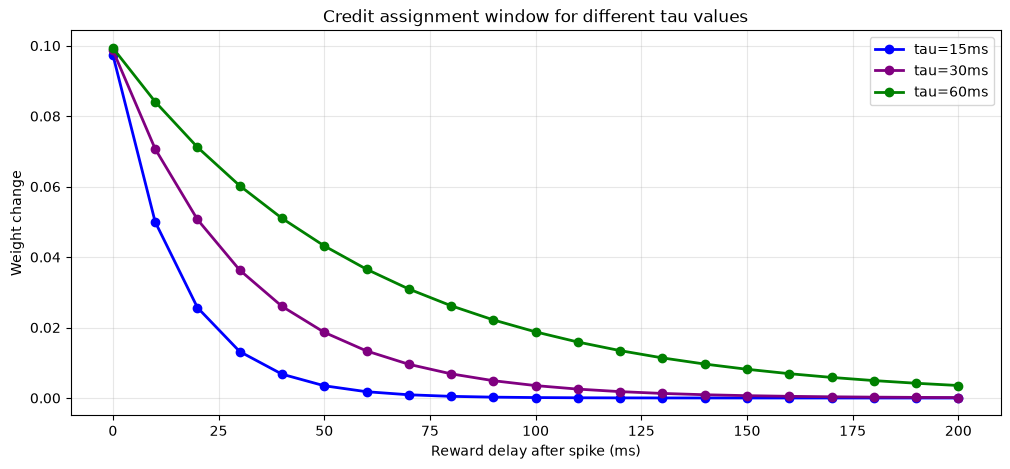

In [5]:
start_scope()

delays = np.arange(0, 201, 10)
taus_to_test = [15, 30, 60]
colors = ['blue', 'purple', 'green']

plt.figure(figsize=(12, 5))

for tau_val, color in zip(taus_to_test, colors):
    weight_changes = []
    
    for delay in delays:
        start_scope()
        
        tau_mem = 10*ms
        tau_trace = tau_val*ms
        
        eqs = '''
        dv/dt = -v/tau_mem : 1
        '''
        output = NeuronGroup(1, eqs, threshold='v>0.8', reset='v=0', method='exact')
        input_neuron = SpikeGeneratorGroup(1, [0], [20]*ms)
        
        stdp_eqs = '''
        w : 1
        detrace/dt = -etrace/tau_trace : 1
        '''
        
        on_pre = '''
        v_post += w
        etrace += 1.0
        '''
        
        S = Synapses(input_neuron, output, stdp_eqs, on_pre=on_pre)
        S.connect()
        S.w = 0.9
        S.etrace = 0
        
        run((20 + delay + 0.5)*ms)
        
        trace_at_reward = S.etrace[0]
        learning_rate = 0.1
        S.w = np.clip(S.w + learning_rate * trace_at_reward, 0, 1)
        
        weight_changes.append(S.w[0] - 0.9)
    
    plt.plot(delays, weight_changes, 'o-', color=color, 
             linewidth=2, markersize=6, label=f'tau={tau_val}ms')

plt.xlabel('Reward delay after spike (ms)')
plt.ylabel('Weight change')
plt.title('Credit assignment window for different tau values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Delayed Reward Learning — Observations & Results

### Why eligibility traces with reward signals?
Notebook 10 established the eligibility trace mechanism in isolation. This 
notebook adds the reward signal with a temporal delay, with the core 
challenge of credit assignment being "which synaptic actions deserve credit when the
reward arrives long after the relevant activity occurred?"

### Architecture
- Single input neuron firing once at t=20ms
- Single output LIF neuron (threshold=0.8)
- Synapse with eligibility trace (`tau_trace=30ms`) and weight
- Reward applied manually at variable delays after the spike
- Weight update: `Δw = learning_rate × trace_at_reward_arrival`

### Debugging notes
Two issues encountered and resolved during development:

**Issue 1 — `(event-driven)` flag prevented continuous decay:**
Using `detrace/dt = -etrace/tau_trace : 1 (event-driven)` caused the trace 
to freeze between spikes rather than decay continuously, producing identical 
weight changes at all delays. Removing the flag restored correct exponential 
decay behaviour.

**Issue 2 — zero-delay sampling artifact:**
At delay=0ms, reward arrived at the exact same timestep as the spike, before 
the trace update was applied — consistent with the discrete-time delay 
documented in notebooks 06, 07, and 10. Fixed by offsetting reward arrival 
by 0.5ms.

### Key finding 1: learning degrades exponentially with reward delay
With `tau_trace=30ms`, weight changes across reward delays:

| Reward delay | Weight change | % of maximum |
|--------------|---------------|--------------|
| 0ms | 0.0987 | 100% |
| 30ms | 0.0363 | 37% |
| 60ms | 0.0134 | 14% |
| 90ms | 0.0049 | 5% |
| 120ms | 0.0018 | 2% |
| 150ms | 0.0007 | ~0% |

Learning degrades smoothly and exponentially, exhibiting not a sharp cutoff, but a 
gradual loss of credit as the trace decays before reward arrives.

### Key finding 2: the 1/e relationship confirms the math
At delay = tau_trace = 30ms, weight change = 0.0363, which is approximately 
37% of the peak (0.0987). This matches the theoretical prediction exactly:
after one time constant, an exponential decays to 1/e ≈ 0.368 of its 
original value. The simulation matches the mathematics precisely.

### Key finding 3: tau directly controls the credit assignment window
Comparing three tau values on the same plot:

| tau | Curve shape | Effective credit window |
|-----|-------------|------------------------|
| 15ms | Steep decay | ~45ms |
| 30ms | Moderate decay | ~90ms |
| 60ms | Shallow decay | ~180ms |

The longer tau produces a shallower decay curve and so the network remains 
"patient", assigning meaningful credit to actions further back in time, while the
shorter tau produces a steeper curve, so the network is more precise but 
impatient, making the reward arrive quickly after the relevant action.

**Biological implication:** different brain regions use different trace 
time constants depending on their computational role. Motor circuits 
tend toward faster traces (precise, immediate credit assignment), while the 
prefrontal circuits involved in planning use slower traces (tolerating 
longer delays between action and outcome). This is a direct neuromorphic 
design parameter — on hardware like Loihi 2, tau is a programmable 
circuit property that determines the system's temporal credit assignment 
behaviour.

### What's next (notebook 12)
With delayed reward learning established, notebook 12 will implement 
**reward prediction error** — the network learns to *expect* reward, 
and the dopamine-like signal shifts from firing at reward delivery to 
firing at the predictive cue. Based on Schultz et al.'s classic 
dopamine neuron recordings, reproduced in a spiking network.